## Astro kod

### Parser

In [406]:
# Parser
import numpy as np
import scipy as sci
import astropy as aspy
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits


from os import listdir
from os.path import isfile, join
import time
from datetime import datetime


# Returnerar lista av (band (int), tidpunkt (datetime), bild_data (np.ndarray av ra, dec, intensitet))
def parseFits(fits_dir):
    # Hämta lista av fits filer från mapp
    fits_files = [fits_file for fits_file in listdir(fits_dir) if isfile(join(fits_dir, fits_file))]

    observations = list()
    date_format = "%Y-%m-%dT%H:%M:%S.%f"

    # Gå igenom varje fits fil
    for fits_file in fits_files:
        # Öppna fitsfil
        # HDUList (Header Data Unit)
        hdul = fits.open(fits_dir + fits_file)
        # hdul.info() # Printar lite info om fitsfilen

        # Header information
        # Se: http://www.alma.inaf.it/images/ArchiveKeyworkds.pdf
        header = hdul[0].header
        #print(repr(header))

        # Få band
        band = int(fits_file[fits_file.find('B')+1])

        # Få observationsdatum och tid
        date_str = header['DATE-OBS']
        date = datetime.strptime(date_str, date_format)

        # Bilddatan
        intensities = np.squeeze(hdul[0].data)

        width, height = intensities.shape
        x_pixels = np.linspace(0, width, width)
        y_pixels = np.linspace(0, height, height)

        # Right ascension
        ra_ref = header['CRVAL1'] # RA referens i relation till Pixel referensen
        ra_delta = header['CDELT1'] # RA delta för varje pixel
        ra_pixel_ref = header['CRPIX1'] # Pixel positionen där RA referens gäller

        # Declination
        dec_ref = header['CRVAL2']
        dec_delta = header['CDELT2']
        dec_pixel_ref = header['CRPIX2']

        # Konvertera från pixel koordinater till ekvatoriella koordinater
        ras = ra_ref + (x_pixels - ra_pixel_ref) * ra_delta
        decs = dec_ref + (y_pixels - dec_pixel_ref) * dec_delta

        observations.append((band, date, ras, decs, intensities))

    return observations


In [407]:
# Parsea fits data för de tre AGB-stjärnorna
R_Dor = parseFits("data/RDor/")
R_Leo = parseFits("data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/RLeo/")
W_Hya = parseFits("data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/WHya/")
#print(R_Dor[0][1])

### Centrum metoder

R Dorados Max intensitet 
R Dorados Gaussisk 
R Leonis Max intensitet 
R Leonis Gaussisk 
W Hydrae Max intensitet 
W Hydrae Gaussisk 
Star plot 


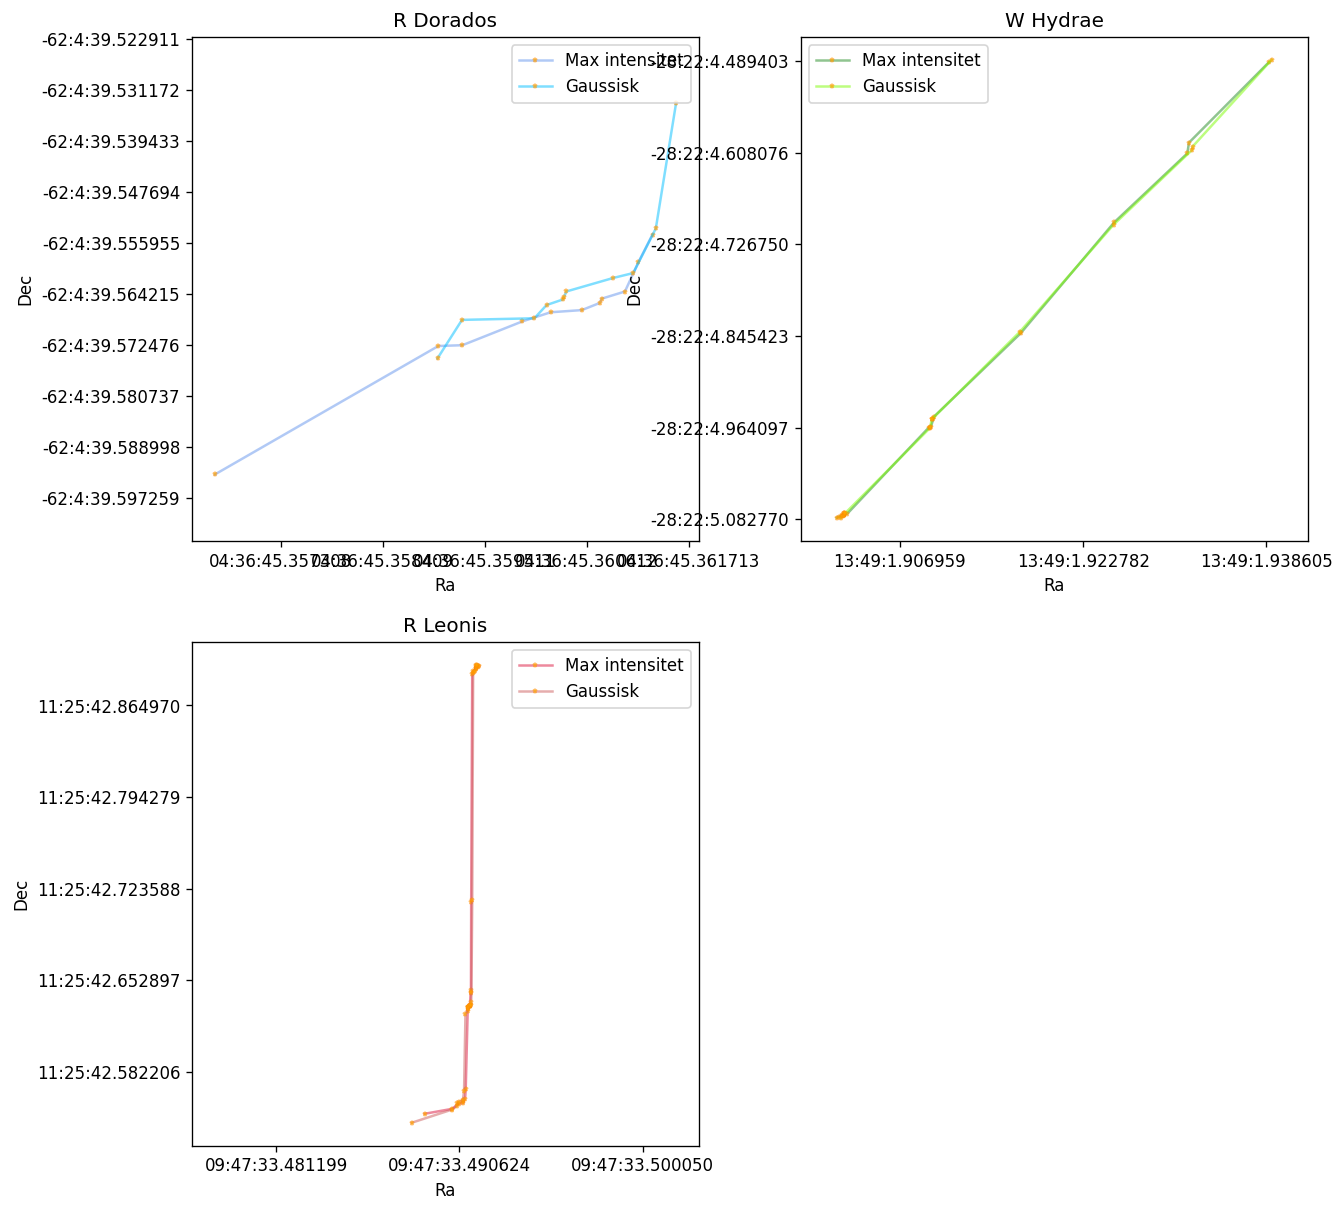

In [408]:
# Centrum metoder

import matplotlib.ticker as tick

# Hitta centrum med ljusaste punkt:
def maxIntensitet(ras, decs, intensities):
    # Hämta index för ljusaste intensitet
    i, j = np.unravel_index(np.argmax(intensities, axis=None), intensities.shape)

    return ras[i], decs[j], intensities[i, j]

# Få centerpunkter med metod och observationer
# Ger tillbaka tidpunkter, ra:s och dec:s
def getCenters(method, observations):
    ts = []
    ras = []
    decs = []

    # Gå igenom varje observaton
    for observation in observations:
        ts.append(observation[1])
        ra, dec, intensitet = method(observation[2], observation[3], observation[4])

        ras.append(ra)
        decs.append(dec)

    # Sortera datan enligt observationstid
    data = np.array([ts, ras, decs])
    data = np.sort(data)

    return data


# Formatterar deklinationen till string format
def decFormatter(dec, pos): 
    dec_deg = int(dec)
    dec_arcmin = int(60 * (dec - dec_deg))
    dec_arcsec = 60 * (60 * (dec - dec_deg) - dec_arcmin)

    #return f"{dec_deg}°{abs(dec_arcmin)}'{abs(dec_arcsec):.3f}''"
    return f"{dec_deg}:{abs(dec_arcmin)}:{abs(dec_arcsec):.6f}"

# Formatterar rektascension till string format
def raFormatter(ra, pos): 
    ra /= 15
    ra_hour = int(ra)
    ra_min = int(60 * (ra - ra_hour))
    ra_sec = 60 * (60 * (ra - ra_hour) - ra_min)

    #return f"{ra_hour}h{abs(ra_min)}m{abs(ra_sec):.3f}s"
    return f"{ra_hour:02d}:{abs(ra_min)}:{abs(ra_sec):.6f}"

# Hämta centrum för stjärnor med max intensitets metod
R_Dor_MaxInt = getCenters(maxIntensitet, R_Dor)
R_Leo_MaxInt = getCenters(maxIntensitet, R_Leo)
W_Hya_MaxInt = getCenters(maxIntensitet, W_Hya)


# Skapa figur för att plotta de olika fallen
fig, axs = plt.subplots(2, 2, figsize=(12, 12), dpi=120)

# Plottar varje graf från centrum och formatterar axlar
def plotter(ax, centers, color, title):
    ax.plot(centers[1], centers[2], marker='*', color=color, markerfacecolor="gold", markeredgecolor="darkorange")
    ax.axis('equal') # 1 grad RA = 1 grad dec
    ax.set_title(title)
    ax.set_xlabel("Ra")
    ax.set_ylabel("Dec")

    # Formattera ticks så att de har rimligt avstånd (för den långa texten) och rätt dec/ra format
    max_scale = max(np.max(centers[1]) - np.min(centers[1]), np.max(centers[2]) - np.min(centers[2]))
    ax.xaxis.set_major_locator(tick.MultipleLocator(base=0.4*max_scale))
    ax.yaxis.set_major_locator(tick.MultipleLocator(base=0.2*max_scale))
    ax.xaxis.set_major_formatter(tick.FuncFormatter(raFormatter))
    ax.yaxis.set_major_formatter(tick.FuncFormatter(decFormatter))

def toAstroDataFile(fname, header, data):
    formatted_data = []
    for data_point in data.T:
        date = data_point[0]
        start = datetime(date.year, 1, 1)
        delta = date - start
        frac_year = date.year + delta.days / (366 if (start.year % 4 == 0) else 365)
        ra = data_point[1]
        dec = data_point[2]
        ra_error = 0.00035 # Dummy value for now
        dec_error = 0.0025 # Dummy value for now
        formatted_data.append((f"{frac_year:.3f}", raFormatter(ra, 0), f"{ra_error:.5f}", decFormatter(dec, 0), f"{dec_error:.5f}"))

    np.savetxt(fname=fname, header="date  RA  RA_error  Dec Dec_error", comments=header + "\n\n# ", X=formatted_data, fmt='%s', delimiter="  ")

def plotMethods(method1, method1_str, method2, method2_str):

    # Beräkna centrum för de två metoderna för varje stjärna
    print("R Dorados", method1_str, "\n=============================")
    R_Dor_center1 = getCenters(method1, R_Dor)
    print("R Dorados", method2_str, "\n=============================")
    R_Dor_center2 = getCenters(method2, R_Dor)
    print("R Leonis", method1_str, "\n=============================")
    R_Leo_center1 = getCenters(method1, R_Leo)
    print("R Leonis", method2_str, "\n=============================")
    R_Leo_center2 = getCenters(method2, R_Leo, debug = True)
    print("W Hydrae", method1_str, "\n=============================")
    W_Hya_center1 = getCenters(method1, W_Hya)
    print("W Hydrae", method2_str, "\n=============================")
    W_Hya_center2 = getCenters(method2, W_Hya)

    # Spara data:
    toAstroDataFile(fname = "R_Dor_1.astrom.dat", header=f"name = R Dorados - {method1_str}", data=R_Dor_center1)
    toAstroDataFile(fname = "R_Dor_2.astrom.dat", header=f"name = R Dorados - {method2_str}", data=R_Dor_center2)
    toAstroDataFile(fname = "R_Leo_1.astrom.dat", header=f"name = R Leonis - {method1_str}", data=R_Leo_center1)
    toAstroDataFile(fname = "R_Leo_2.astrom.dat", header=f"name = R Leonis - {method2_str}", data=R_Leo_center2)
    toAstroDataFile(fname = "W_Hya_1.astrom.dat", header=f"name = W Hydrae - {method1_str}", data=W_Hya_center1)
    toAstroDataFile(fname = "W_Hya_2.astrom.dat", header=f"name = W Hydrae - {method2_str}", data=W_Hya_center2)

    print("Star plot", "\n=============================")
    # Skapa figur för att plotta de olika fallen
    fig, axs = plt.subplots(2, 2, figsize=(12, 12), dpi=120)

    # Plotta alla centrum
    axs[0,0].set_title("R Dorados")
    axs[1,0].set_title("R Leonis")
    axs[0,1].set_title("W Hydrae")

    plotter(axs[0,0], R_Dor_center1, "cornflowerblue", method1_str)
    plotter(axs[1,0], R_Leo_center1, "crimson", method1_str)
    plotter(axs[0,1], W_Hya_center1, "forestgreen", method1_str)

    plotter(axs[0,0], R_Dor_center2, "deepskyblue", method2_str)
    plotter(axs[1,0], R_Leo_center2, "indianred", method2_str)
    plotter(axs[0,1], W_Hya_center2, "lawngreen", method2_str)

    axs[0,0].legend()
    axs[1,0].legend()
    axs[0,1].legend()

    axs[1,1].set_axis_off()

# Beräkna centrum för max intensitet och gaussisk, plotta och jämför
plotMethods(maxIntensitet, "Max intensitet", gaussIntensitet, "Gaussisk")


### Parallax (+Bootstrap)

In [409]:
# Bootstrap

# Parallax

def sun_longitude(date): # date is decimalformat of year 
    
    # Data from https://ssd.jpl.nasa.gov/horizons/app.html#/
    J2000 = 2000 - 0.5/365.25 # Standard epoch J2000, but remove half a day to be at midnight
    Loam = 163.974 
    Aop = 297.767
    e = 0.0167

    day = (date-J2000)*365.25 # Convert year to days since J2000
    M = (358.189 + 0.9856*day) # Mean anomaly, deg
    L = M + Loam + Aop # Mean longitude, deg
    M_rad = np.deg2rad(M)

    ecl_long = L + 2*e*np.sin(M_rad)+(5/4)*(e**2)*np.sin(2*M_rad)
    long_theta = np.mod(ecl_long, 360)
    return long_theta

def bary_coords(date):
    # To start, we assume circular orbit. Then X = cos(longitude) and Y = sin(longitude)
    longitude = np.deg2rad(sun_longitude(date))
    eps = np.deg2rad(23.439)

    X = np.cos(longitude)
    Y = np.sin(longitude)*np.cos(eps)
    Z = np.sin(longitude)*np.sin(eps)

    return X, Y, Z


# Get factors that depends on barycentric coordinates
def P(date, refpos):
    RA_ref = np.deg2rad(refpos[0])
    DEC_ref = np.deg2rad(refpos[1])
    X, Y, Z = bary_coords(date)

    p = (X*np.sin(RA_ref) - Y*np.cos(RA_ref))/np.cos(DEC_ref)
    return p

def Q(date, refpos):
    X, Y, Z =  bary_coords(date)
    RA_ref = np.deg2rad(refpos[0])
    DEC_ref = np.deg2rad(refpos[1])

    q = (X*np.cos(RA_ref)*np.sin(DEC_ref) + Y*np.sin(RA_ref)*np.sin(DEC_ref) - Z*np.cos(DEC_ref))
    return q


def model(date, *params):

    dRA0, dDec0, parallax, pm_ra, pm_dec = params
    t = date - ref_ep

    ra_model = dRA0 + parallax * P(date, refpos) + pm_ra * t
    dec_model = dDec0 + parallax * Q(date, refpos) + pm_dec * t
    
    return np.concatenate([ra_model, dec_model])

def model_wpm(date, *params): # without proper motion

    dRA0, dDec0, parallax, pm_ra, pm_dec = params
    t = date - ref_ep

    ra_model = dRA0 + parallax * P(date, refpos)
    dec_model = dDec0 + parallax * Q(date, refpos)
    
    return np.concatenate([ra_model, dec_model])

In [410]:
# Analys

# Code for fitting to model
def fitting(date, dra, ddec, fix=None):
    # get limits for each parameter
    bounds = ([-np.inf, -np.inf, 0., -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf, np.inf])

    initial_guess = [dra[0], ddec[0], 1.0, 0., 0.]
    y_data = np.concatenate([dra, ddec])
    # make the fit
    params, covariance = sci.optimize.curve_fit(model, date, y_data, p0 = initial_guess, bounds = bounds)

    return params, covariance

### Analys

In [411]:
data = W_Hya_MaxInt

deg2mas = 3.6e6

def time_convert(dates): # use decimal years instead of datetime format
    
    year_start = datetime(dates.year, 1, 1)
    next_year_start = datetime(dates.year + 1, 1, 1)

    year_length = (next_year_start - year_start).total_seconds()
    seconds_into_year = (dates - year_start).total_seconds()

    return dates.year + seconds_into_year / year_length


dates = np.array([time_convert(data[0][i]) for i in range(len(data[0]))])
refpos = [data[1][0], data[2][0]]
ref_ep = dates[0]
ras = data[1]
decs = data[2]
dras = (ras-ras[0])*deg2mas*np.cos(np.deg2rad(decs[0]))
ddecs = (decs-decs[0])*deg2mas

params, covariance = fitting(dates, dras, ddecs)

# Create hypothetical dates for plotting
hyp_dates = np.linspace(dates[0], dates[-1], 1000)
year_data = ref_ep + np.linspace(0,1,1000)

# Use model on the hypothetical data
model_data = model(hyp_dates, *params)
model_data_wpm = model_wpm(year_data, *params)
model_data_obs = model_wpm(dates, *params)

ras_data = refpos[0] + model_data[:len(model_data)//2]/(deg2mas*np.cos(np.deg2rad(decs[0])))
decs_data = refpos[1] + model_data[len(model_data)//2:]/deg2mas

dra_data = (model_data_wpm[:len(model_data_wpm)//2])
ddec_data = (model_data_wpm[len(model_data_wpm)//2:])
dra_data_obs = (model_data_obs[:len(model_data_obs)//2])
ddec_data_obs = (model_data_obs[len(model_data_obs)//2:])


# Calculate and print parallax in mas
parallax = params[2]/1000 #Convert to as to use distance formula

distance = 1/parallax # 1 AU / parallax in as = distance in AU:s
# print(distance/(1.1e7)) # print ratio between found distance and "acutal" distace (around 1.1e7 for R Dor)
print(f'Parallax in mas: {parallax*1000}')

Parallax in mas: 162.07709631295063


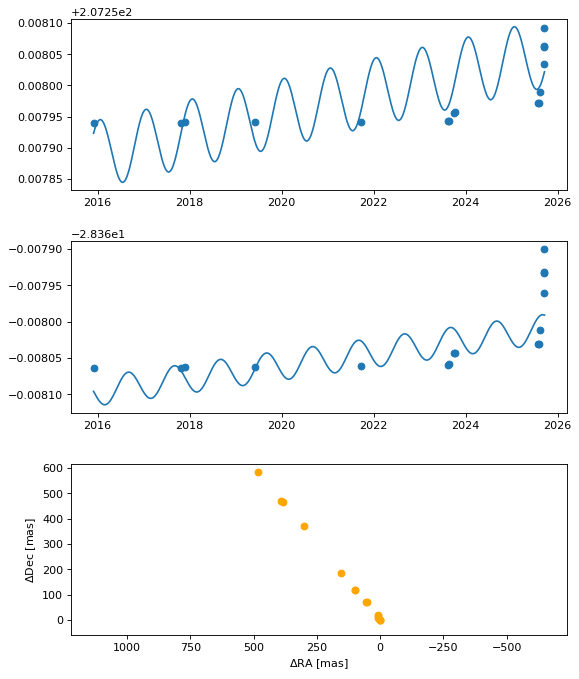

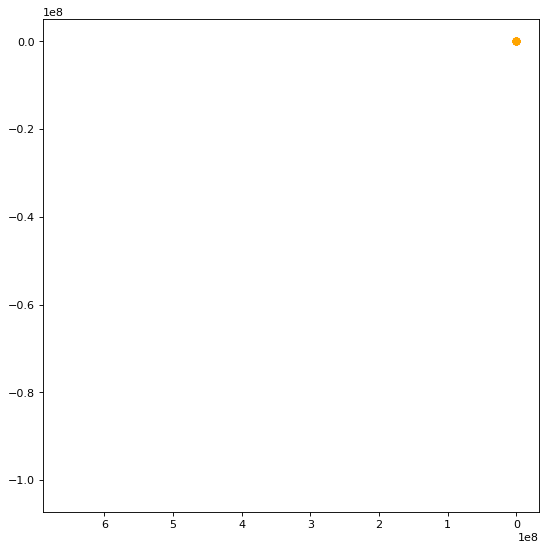

In [412]:
#make some plots

fig, ax = plt.subplots(3,1, figsize = (8, 10), dpi = 80)

plt.subplots_adjust(hspace=0.3)
ax[0].plot(hyp_dates, ras_data)
ax[0].scatter(dates, ras)

ax[1].plot(hyp_dates, decs_data)
ax[1].scatter(dates, decs)

ax[2].plot(ras_data, decs_data)
ax[2].scatter(dras, ddecs, color = 'orange')
ax[2].set_xlabel(r'$\Delta$RA [mas]')
ax[2].set_ylabel(r'$\Delta$Dec [mas]')
ax[2].axis('equal') # 1 grad RA = 1 grad dec
ax[2].invert_xaxis()
# ax.yaxis.set_major_locator(tick.MultipleLocator(100))
# ax.xaxis.set_major_locator(tick.MultipleLocator(100))
plt.show()

fig, ax = plt.subplots(figsize = (8, 8), dpi = 80)

plt.plot(ras_model, decs_model)
plt.scatter(ras, decs, color = 'orange')
ax.invert_xaxis()


